In [1]:
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
song_paths = {
    "Kanye West": "./song1/kanye.mp3",
    "Cardi B": "./song2/wap.mp3",
    "Elton John": "./song3/islandgirl.mp3",
    "Tom Macdonald": "./song4/whiteboy.mp3",
    "Kanye West (AI)": "./song1/kanye_new.mp3",
    "Cardi B (AI)": "./song2/wap_new.mp3",
    "Elton John (AI)": "./song3/islandgirl_new.mp3",
    "Tom Macdonald (AI)": "./song4/whiteboy_new.mp3"
}



max_duration = 360  
songs = {}

for name, path in song_paths.items():
    y, sr = librosa.load(path, duration=max_duration, mono=True)
    songs[name] = {"y": y, "sr": sr}

In [3]:

song_sections = {
    "Kanye West": [
        (0, 50, "Verse 1"),
        (51, 76, "Chorus"),
        (77, 90, "Verse 2"),
        (91, 161, "Chorus")
    ],
    "Cardi B": [
        (0, 14, "Intro"),
        (15, 28, "Chorus"),
        (29, 56, "Verse 1"),
        (57, 71, "Verse 2"),
        (72, 85, "Chorus"),
        (86, 115, "Verse 3"),
        (116, 137, "Verse 4"),
        (138, 165, "Chorus"),
        (166, 187, "Outro"),
    ],
    "Elton John": [
        (0, 33, "Verse 1"),
        (34, 69, "Chorus"),
        (70, 102, "Verse 2"),
        (103, 222, "Chorus"),
        (104, 171, "Solo"),
        (172, 222, "Chorus")
    ],
    "Tom Macdonald": [
        (0, 50, "Verse 1"),
        (51, 61, "Chorus"),
        (62, 73, "Post-Chorus"),
        (73, 107, "Verse 2"),
        (108, 118, "Chorus"),
        (119, 129, "Post-Chorus"),
        (130, 176, "Verse 3"),
        (177, 220, "Verse 4"),
        (221, 231, "Bridge"),
        (232, 271, "Chorus"),
        (242, 253, "Post-Chorus"),
        (254, 264, "Chorus")
        
    ],
    "Kanye West (AI)": [
        (0, 57, "Verse 1"),
        (58, 85, "Chorus"),
        (86, 97, "Verse 2"),
        (98, 136, "Chorus")
    ],
    "Cardi B (AI)": [
        (0,  28, "Intro"),
        (29, 42, "Chorus"),
        (43, 72, "Verse 1"),
        (73, 99, "Verse 2"),
        (100, 115, "Chorus"),
        (116, 143, "Verse 3"),
        (144, 166, "Verse 4"),
        (167, 194, "Chorus"),
        (195, 217, "Outro"),
    ],
    "Elton John (AI)": [
        (0, 33, "Verse 1"),
        (34, 69, "Chorus"),
        (70, 96, "Verse 2"),
        (97, 133, "Chorus"),
        (134, 161, "Solo"),
        (162, 221, "Chorus")
    ],
    "Tom Macdonald (AI)": [
        (0, 55, "Verse 1"),
        (56, 67, "Chorus"),
        (68, 78, "Post-Chorus"),
        (79, 113, "Verse 2"),
        (114, 123, "Chorus"),
        (124, 135, "Post-Chorus"),
        (136, 174, "Verse 3"),
        (175, 211, "Verse 4"),
        (212, 222, "Bridge"),
        (223, 235, "Chorus"),
        (236, 246, "Post-Chorus"),
        (247, 270, "Chorus")
        
    ]
}




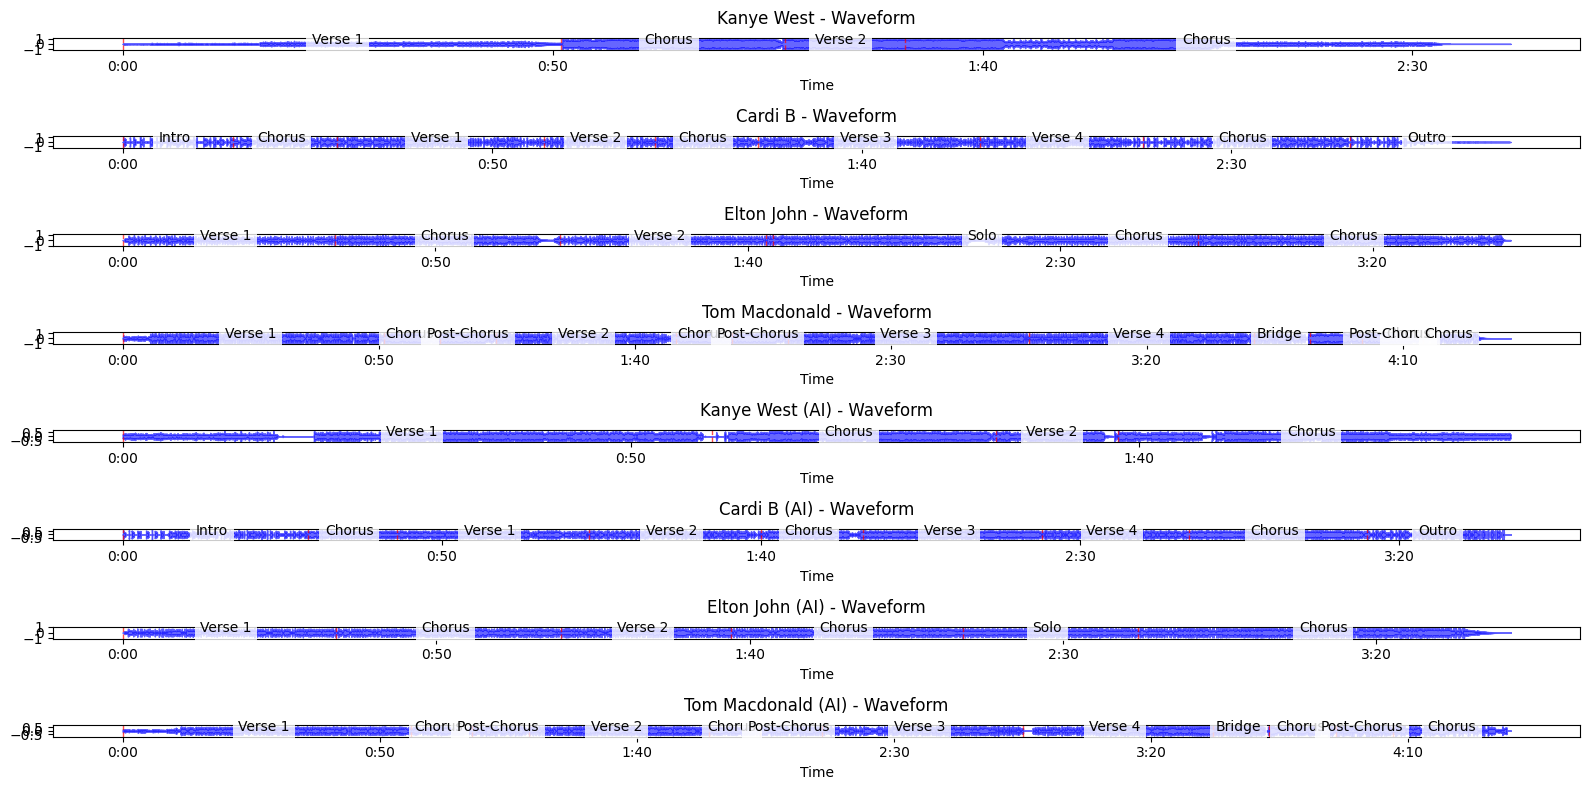

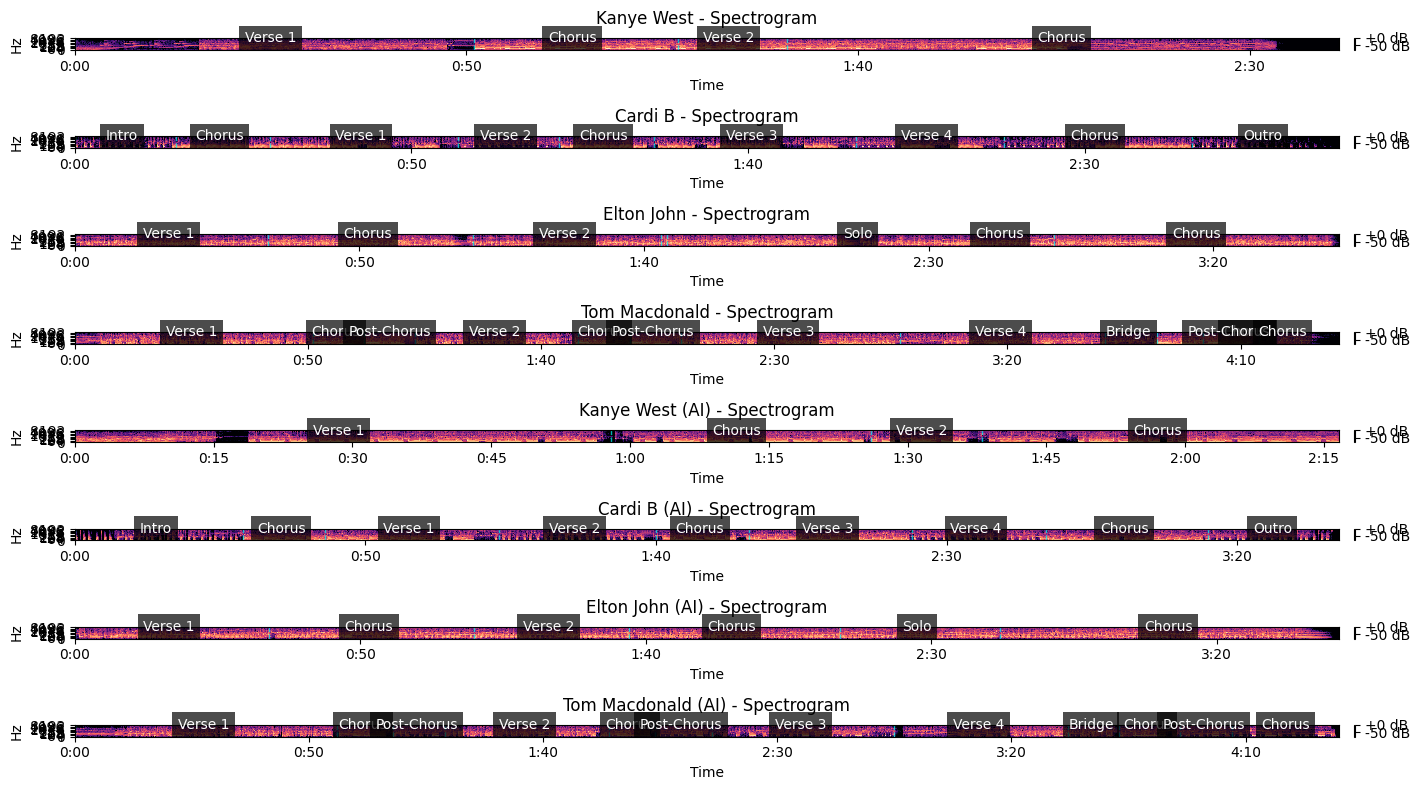

In [4]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# --- WAVEFORMS (All artists in one plot) ---
plt.figure(figsize=(16, 8))  # Wider and taller to accommodate all waveforms

for i, (artist, data) in enumerate(songs.items(), 1):
    y = data['y']
    sr = data['sr']
    
    plt.subplot(len(songs), 1, i)  # Vertical stacking (N rows, 1 column)
    librosa.display.waveshow(y, sr=sr, color='b', alpha=0.6)
    plt.title(f'{artist} - Waveform', pad=10)
    
    # Section markers
    for start, end, label in song_sections[artist]:
        plt.axvline(x=start, color='r', linestyle='--', linewidth=1, alpha=0.7)
        plt.text(x=start + (end-start)/2, y=0.8*max(y), s=label,
                ha='center', va='center', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

# --- SPECTROGRAMS (All artists in one plot) ---
plt.figure(figsize=(16, 8))  # Same dimensions for consistency

for i, (artist, data) in enumerate(songs.items(), 1):
    y = data['y']
    sr = data['sr']
    
    plt.subplot(len(songs), 1, i)  # Vertical stacking
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', cmap='magma')
    plt.colorbar(format='%+2.0f dB', pad=0.01)
    plt.title(f'{artist} - Spectrogram', pad=10)
    
    # Section markers
    for start, end, label in song_sections[artist]:
        plt.axvline(x=start, color='cyan', linestyle='--', linewidth=1, alpha=0.7)
        plt.text(x=start + (end-start)/2, y=plt.ylim()[1]*0.9, s=label,
                color='white', ha='center', va='center',
                bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

In [5]:


def extract_intensity(y, sr):
    S = np.abs(librosa.stft(y))
    intensity_db = librosa.amplitude_to_db(S, ref=np.max)
    return np.mean(intensity_db)



def extract_audio_features(y, sr):
    # Spectral features
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    spec_flatness = np.mean(librosa.feature.spectral_flatness(y=y))
    zero_cross_rate = np.mean(librosa.feature.zero_crossing_rate(y))
    
    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    
    return {
        "spectral_centroid": spec_centroid,
        "spectral_bandwidth": spec_bandwidth,
        "spectral_flatness": spec_flatness,
        "zero_cross_rate": zero_cross_rate,
        "tempo": tempo
    }

In [6]:
results = []

for name, data in songs.items():
    y, sr = data["y"], data["sr"]
    
    intensity = extract_intensity(y, sr)
    audio_feats = extract_audio_features(y, sr)
    
    # Determine type
    if "(AI)" in name:
        artist_name = name.replace(" (AI)", "")
        track_type = "AI"
    else:
        artist_name = name
        track_type = "Original"
    
    track_result = {
        "artist": artist_name,
        "type": track_type,
        "intensity": intensity,
        **audio_feats
    }
    
    results.append(track_result)


In [7]:
df = pd.DataFrame(results)

# Optional: round certain columns for readability
df['tempo'] = df['tempo'].apply(lambda x: x[0].round(2))
for col in df.columns:
    if col.startswith("mfcc_"):
        df[col] = df[col].round(2)



# Save to CSV
df.to_csv("song_features.csv", index=False)

In [8]:
df

,artist,type,intensity,spectral_centroid,spectral_bandwidth,spectral_flatness,zero_cross_rate,tempo
0,Kanye West,Original,-60.148338,1651.269802,1972.668768,0.053582,0.061830,99.38
1,Cardi B,Original,-62.657478,2469.338609,2574.975686,0.025156,0.104263,136.00
2,Elton John,Original,-51.809776,2356.714649,2705.828678,0.019349,0.092762,143.55
3,Tom Macdonald,Original,-51.051857,2827.653963,2619.515628,0.042172,0.139071,86.13
4,Kanye West,AI,-52.366123,2928.356719,2767.925108,0.029915,0.112273,152.00
5,Cardi B,AI,-55.275909,2989.438598,2840.686115,0.037405,0.133413,136.00
6,Elton John,AI,-50.517242,2244.574814,2441.434609,0.020200,0.096174,143.55
7,Tom Macdonald,AI,-54.819172,2645.735367,2651.514990,0.031570,0.113071,172.27


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots
plt.figure(figsize=(12, 5))  # Wider figure to accommodate both plots

# First subplot - Spectral Centroid (a)
plt.subplot(1, 2, 1)
sns.barplot(data=df, x="artist", y="spectral_centroid", palette="viridis")
plt.title("(a) Spectral Centroid by Artist", fontweight='bold', pad=10)
plt.ylabel("Spectral Centroid (Hz)")
plt.xticks(rotation=45, ha='right')

# Second subplot - Spectral Flatness (b)
plt.subplot(1, 2, 2)
sns.barplot(data=df, x="artist", y="spectral_flatness", palette="plasma")
plt.title("(b) Spectral Flatness by Artist", fontweight='bold', pad=10)
plt.ylabel("Spectral Flatness")
plt.xticks(rotation=45, ha='right')

# Adjust layout and save
plt.tight_layout()
plt.savefig('plots/centroid_flatness.png', dpi=300, bbox_inches='tight')
plt.close()

C:\Users\jiyon\AppData\Local\Temp\ipykernel_22100\2806361170.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="artist", y="spectral_centroid", palette="viridis")
C:\Users\jiyon\AppData\Local\Temp\ipykernel_22100\2806361170.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="artist", y="spectral_flatness", palette="plasma")


Higher spectral centroid - brighter, sharper

Lower specrtal centroid - darker, warmer, duller

In [10]:
df

,artist,type,intensity,spectral_centroid,spectral_bandwidth,spectral_flatness,zero_cross_rate,tempo
0,Kanye West,Original,-60.148338,1651.269802,1972.668768,0.053582,0.061830,99.38
1,Cardi B,Original,-62.657478,2469.338609,2574.975686,0.025156,0.104263,136.00
2,Elton John,Original,-51.809776,2356.714649,2705.828678,0.019349,0.092762,143.55
3,Tom Macdonald,Original,-51.051857,2827.653963,2619.515628,0.042172,0.139071,86.13
4,Kanye West,AI,-52.366123,2928.356719,2767.925108,0.029915,0.112273,152.00
5,Cardi B,AI,-55.275909,2989.438598,2840.686115,0.037405,0.133413,136.00
6,Elton John,AI,-50.517242,2244.574814,2441.434609,0.020200,0.096174,143.55
7,Tom Macdonald,AI,-54.819172,2645.735367,2651.514990,0.031570,0.113071,172.27


Higher flatness means noisier, lower is pure singing note like a flute

In [11]:
order = ["Kanye West", "Cardi B", "Elton John", "Tom Macdonald"]


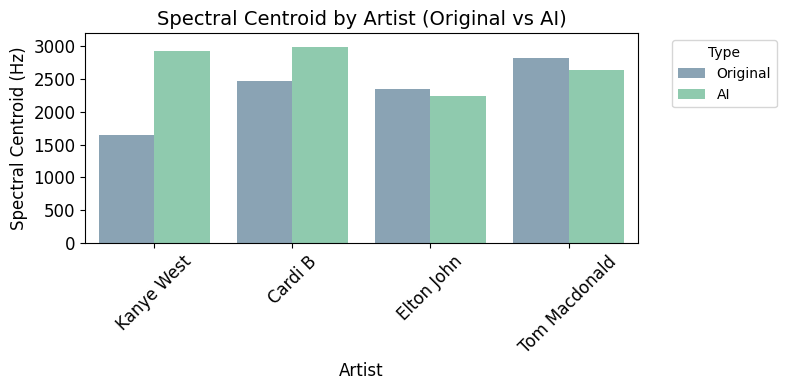

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=df,
    x="artist",
    y="spectral_centroid",  # <-- make sure this matches what you want
    hue="type",
    palette="viridis",
    order=order,
    dodge=True,
    alpha=0.6
)

plt.title("Spectral Centroid by Artist (Original vs AI)", fontsize=14)
plt.ylabel("Spectral Centroid (Hz)", fontsize=12)
plt.xlabel("Artist", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 3200)  # adjust scale for centroid
plt.legend(
    title="Type",
    bbox_to_anchor=(1.05, 1),  # place legend just outside right
    loc="upper left",
    fontsize=10
)
plt.tight_layout()
plt.show()


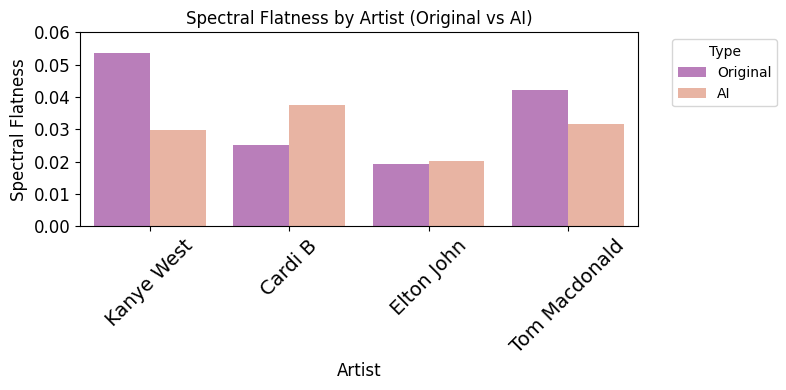

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["Kanye West", "Cardi B", "Elton John", "Tom Macdonald"]

plt.figure(figsize=(8,4))
sns.barplot(
    data=df,
    x="artist",
    y="spectral_flatness",
    hue="type",          # Original vs AI
    palette="plasma",
    order=order,
    dodge=True,           # side-by-side bars
    alpha=0.6
)

plt.title("Spectral Flatness by Artist (Original vs AI)")
plt.ylabel("Spectral Flatness", fontsize=12)
plt.xlabel("Artist", fontsize=12)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=12)
plt.ylim(0, 0.06)
plt.legend(
    title="Type",
    bbox_to_anchor=(1.05, 1),  # place legend just outside right
    loc="upper left",
    fontsize=10
)
plt.tight_layout()
plt.show()


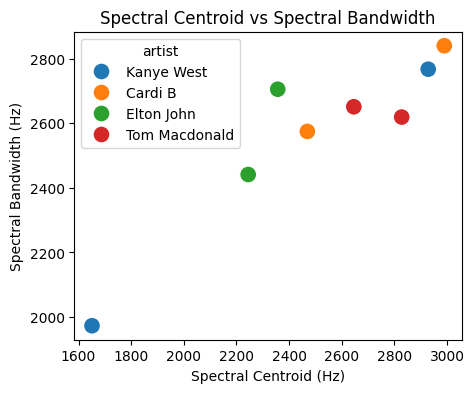

In [14]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df,
    x="spectral_centroid",
    y="spectral_bandwidth",
    hue="artist",
    s=150,
    palette="tab10"
)
plt.title("Spectral Centroid vs Spectral Bandwidth")
plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.show()


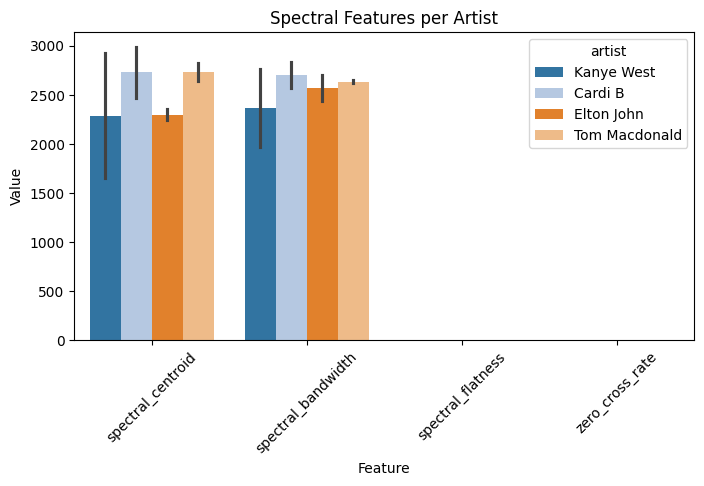

In [15]:
spectral_features = [
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_flatness",
    "zero_cross_rate"
]

# Melt for plotting
df_melted = df.melt(
    id_vars="artist",
    value_vars=spectral_features,
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_melted,
    x="Feature",
    y="Value",
    hue="artist",
    palette="tab20"
)
plt.title("Spectral Features per Artist")
plt.xticks(rotation=45)
plt.show()


In [16]:
mfcc_cols = [f'mfcc_{i}' for i in range(1,14)]
avg_mfcc = df.groupby('artist')[mfcc_cols].mean().T.reset_index()
avg_mfcc = avg_mfcc.rename(columns={'index':'mfcc_coeff'})

# Melt for seaborn
melted = avg_mfcc.melt(id_vars='mfcc_coeff', var_name='artist', value_name='value')

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=melted, x='mfcc_coeff', y='value', hue='artist', 
             marker='o', linewidth=2.5)
plt.title('MFCC Patterns Across Artists')
plt.xlabel('MFCC Coefficient')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

KeyError: "Columns not found: 'mfcc_1', 'mfcc_12', 'mfcc_9', 'mfcc_6', 'mfcc_3', 'mfcc_2', 'mfcc_5', 'mfcc_7', 'mfcc_4', 'mfcc_8', 'mfcc_11', 'mfcc_10', 'mfcc_13'"

MFCC 1	Average signal energy (loudness)	Overall track volume/amplitude

MFCC 2	Balance of low vs. high frequencies	Brightness/darkness of sound

MFCC 3	Mid-frequency spectral shape	Presence of vocals/instruments (300–1kHz)

MFCC 4	Harmonic structure	Distinguishes pitched vs. percussive sounds

MFCC 5	Mid-high frequency energy	Attack of instruments (1–3kHz)

MFCC 6–8	Spectral roughness/texture	Distortion, raspiness, or smoothness

MFCC 9–13	Fine spectral details	Reverb, noise, articulation nuances

[0.06545977 0.08146871 0.09451892 ... 0.10156147 0.08038842 0.05803952]
[2.9178715e-04 7.1318001e-03 1.9645177e-01 ... 5.5298615e-06 4.0884420e-06
 3.2705145e-06]
[1.6411980e-04 1.6680053e-04 1.9682871e-04 ... 3.8639719e-06 4.2005618e-06
 3.9831675e-06]
[5.9640175e-03 3.3816144e-02 4.8737295e-02 ... 1.3598525e-05 2.6221942e-05
 2.6180702e-05]


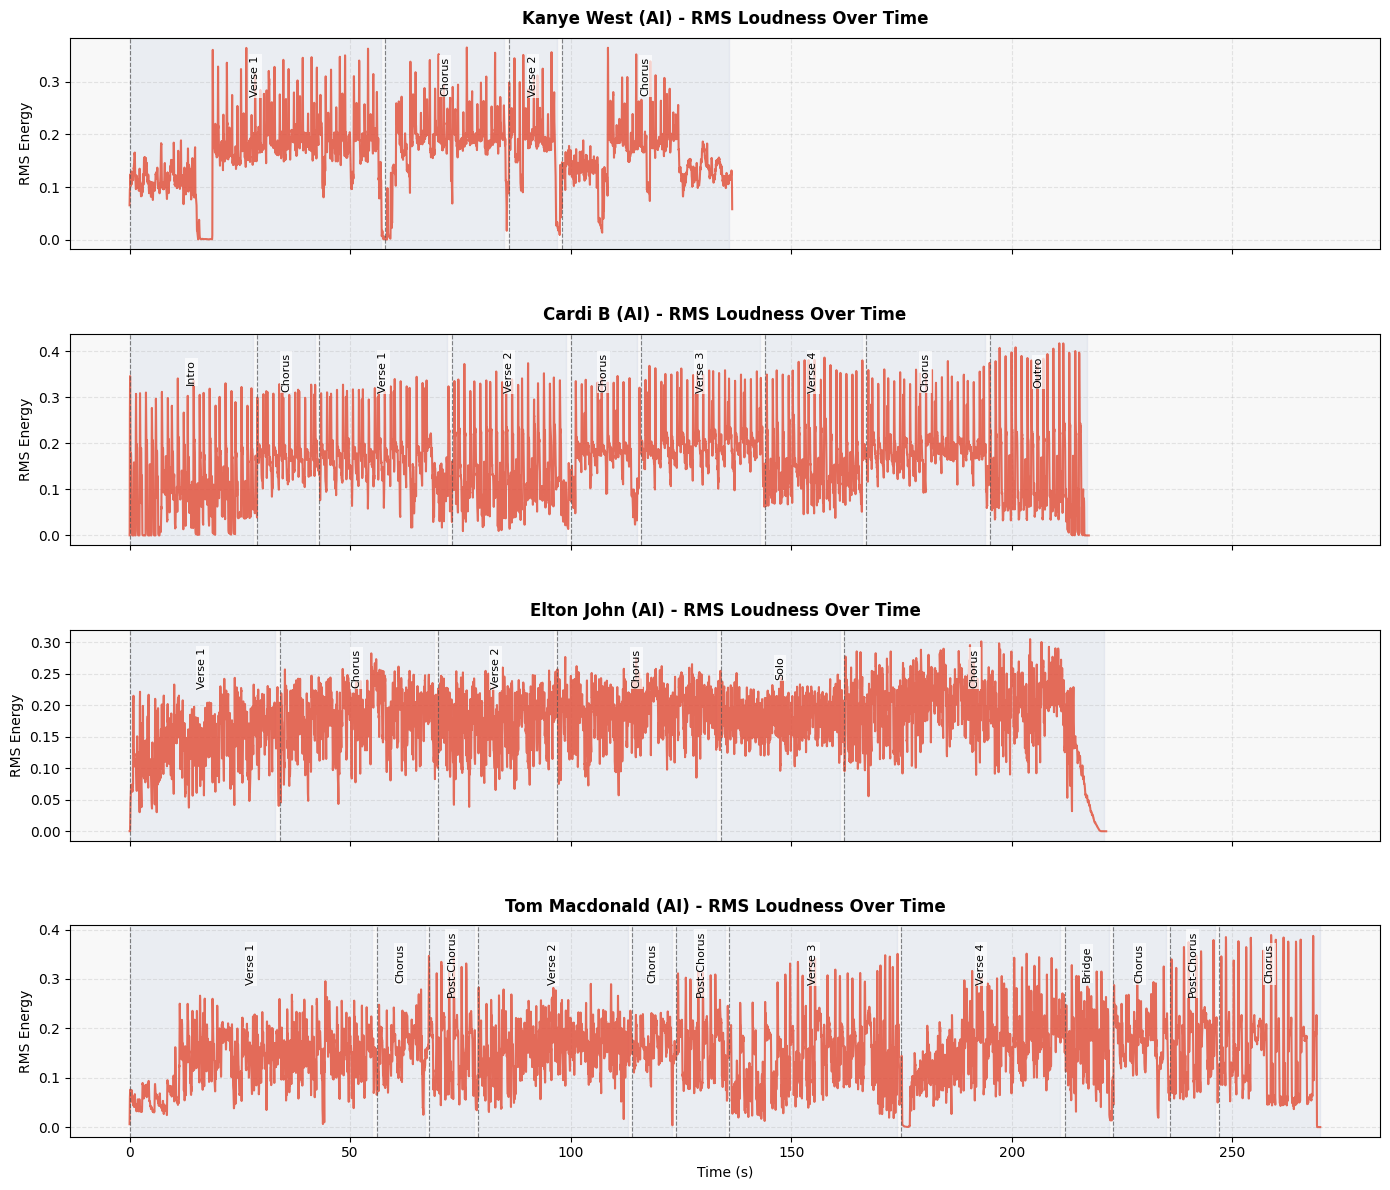

In [ ]:
def plot_rms_all_artists():
    # Create figure with adjusted settings
    fig, axs = plt.subplots(len(songs), 1, figsize=(14, 3*len(songs)), 
                           sharex=True, facecolor='white')
    
    if len(songs) == 1:
        axs = [axs]  # Handle single artist
    
    for row, artist in enumerate(songs.keys()):
        y = songs[artist]["y"]
        sr = songs[artist]["sr"]
        sections = song_sections[artist]
        
        # Compute RMS
        rms = librosa.feature.rms(y=y)[0]
        print(rms)
        rms_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr)
        
        # Plot RMS with better styling
        axs[row].plot(rms_times, rms, color="#E24A33", linewidth=1.5, alpha=0.8)
        axs[row].set_title(f"{artist} - RMS Loudness Over Time", 
                          fontsize=12, pad=10, fontweight='bold')
        axs[row].set_ylabel("RMS Energy", fontsize=10)
        axs[row].grid(True, linestyle='--', alpha=0.3)
        
        # Set facecolor for the plot
        axs[row].set_facecolor('#f8f8f8')
        
        # Add vertical lines and shaded sections
        for start, end, label in sections:
            # Vertical line at section start
            axs[row].axvline(x=start, color='#555555', linestyle='--', linewidth=0.8, alpha=0.7)
            
            # Shaded section
            axs[row].axvspan(start, end, color='#4C72B0', alpha=0.08)
            
            # Section label
            axs[row].text((start+end)/2, max(rms)*0.85, label, rotation=90,
                         fontsize=8, ha='center', va='center', 
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))
    
    # Final adjustments
    axs[-1].set_xlabel("Time (s)", fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)  # Add some space between subplots
    plt.show()

# Run it
plot_rms_all_artists()

In [ ]:
import librosa
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Initialize results storage
results = []

for artist, data in songs.items():
    y = data["y"]
    sr = data["sr"]
    
    # 1. Waveform Statistics
    peak = np.max(np.abs(y))
    std = np.std(y)
    
    # 2. RMS Calculations
    rms = librosa.feature.rms(y=y)[0]
    avg_rms = np.mean(rms)
    max_rms = np.max(rms)
    min_rms = np.min(rms)
    
    # 3. Dynamic Range
    dynamic_range_db = 20 * np.log10(peak / (avg_rms + 1e-10))  # Avoid division by zero
    
    results.append({
        'Artist': artist,
        'Duration': len(y)/sr,
        'Peak Amplitude': peak,
        'Waveform STD': std,
        'Avg RMS': avg_rms,
        'Max RMS': max_rms,
        'Min RMS': min_rms,
        'Dynamic Range (dB)': dynamic_range_db
    })

# Create DataFrame
results_df = pd.DataFrame(results).set_index('Artist')

results_df

,Duration,Peak Amplitude,Waveform STD,Avg RMS,Max RMS,Min RMS,Dynamic Range (dB)
Artist,,,,,,,
Kanye West (AI),136.64,0.683512,0.174939,0.164173,0.364990,0.000348,12.388873
Cardi B (AI),217.48,0.806611,0.179148,0.162053,0.417123,0.000003,13.940124
Elton John (AI),221.44,0.934735,0.180530,0.173124,0.305144,0.000003,14.646612
Tom Macdonald (AI),269.96,0.786665,0.164607,0.151668,0.388863,0.000002,14.297907


In [ ]:
songs

{'Kanye West (AI)': {'y': array([ 0.00870741,  0.01936682,  0.02729537, ..., -0.01053798,
         -0.0150142 , -0.01109885], shape=(3012912,), dtype=float32),
  'sr': 22050},
 'Cardi B (AI)': {'y': array([-7.6282548e-04, -1.3385378e-03, -9.0736395e-04, ...,
          1.3759552e-06,  5.7282853e-07, -5.8066917e-07],
        shape=(4795434,), dtype=float32),
  'sr': 22050},
 'Elton John (AI)': {'y': array([-1.2475258e-04, -4.3069676e-04, -3.5684102e-04, ...,
          5.3236517e-06, -4.1232825e-06, -1.8455900e-06],
        shape=(4882752,), dtype=float32),
  'sr': 22050},
 'Tom Macdonald (AI)': {'y': array([-4.5425212e-04, -6.6154473e-04, -5.0713180e-04, ...,
         -6.5108892e-05, -5.7490048e-05, -3.0621817e-05],
        shape=(5952618,), dtype=float32),
  'sr': 22050}}